In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torchvision import datasets

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


In [3]:
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/kaggle/input/models/joercharles/cifar-10/pytorch/default/1/CIFAR-10_model.pth


In [4]:
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

class CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.CNN1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.bn1  = nn.BatchNorm2d(32)
        self.CNN2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.bn2  = nn.BatchNorm2d(64)
        self.CNN3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.bn3  = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()
        self.mxp  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.lin1 = nn.Linear(2048, 1024)
        self.lin2 = nn.Linear(1024, 512)
        self.lin3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.CNN1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.mxp(x)
        x = self.CNN2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.mxp(x)
        x = self.CNN3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.flatten(x)
        x = self.lin1(x)
        x = self.relu(x)
        x = self.lin2(x)
        x = self.relu(x)
        x = self.lin3(x)
        return x

In [5]:
# Paste path from Cell 3
weights_path = '/kaggle/input/models/joercharles/cifar-10/pytorch/default/1/CIFAR-10_model.pth'

cifar_model = CIFAR()

# Strip DataParallel prefix since it was saved with DataParallel
state_dict = torch.load(weights_path, map_location=device)
state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}

cifar_model.load_state_dict(state_dict)
cifar_model = cifar_model.to(device)
cifar_model.eval()
print("Model loaded!")

Model loaded!


100%|██████████| 170M/170M [00:09<00:00, 17.8MB/s] 


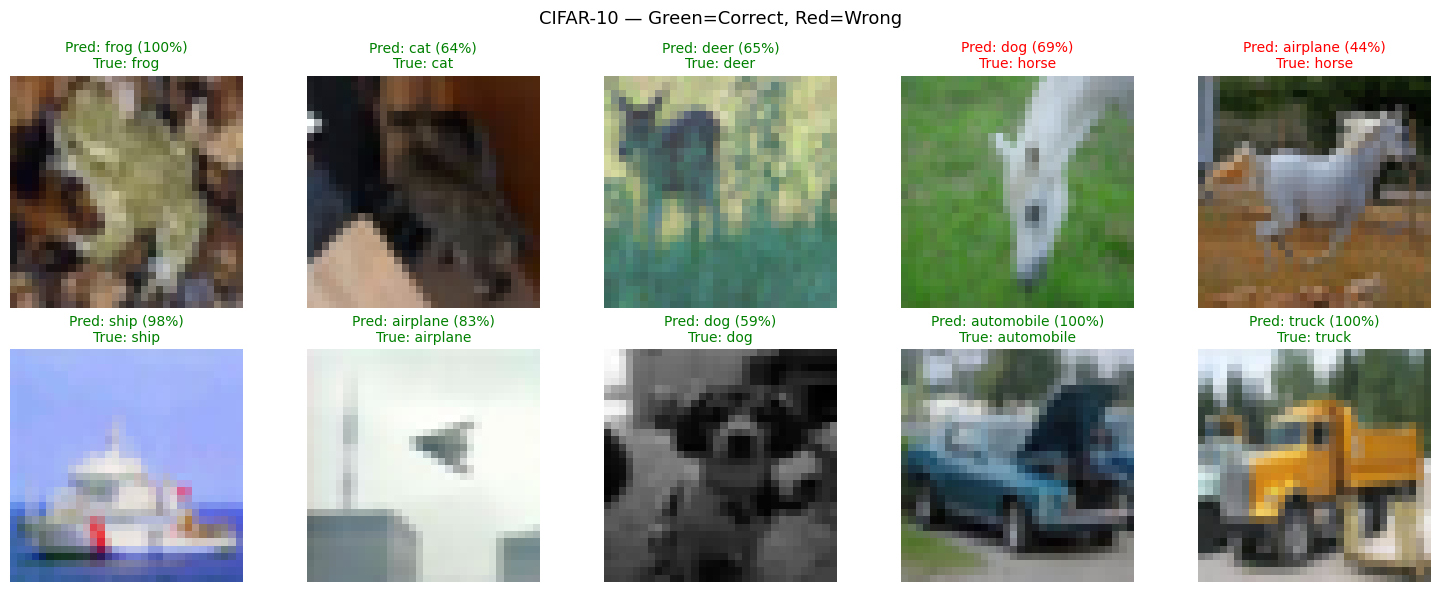

In [6]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_data = datasets.CIFAR10(root='data', train=False, download=True, transform=transform_test)
indices = np.random.choice(len(test_data), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_data[idx]
        output = cifar_model(image.unsqueeze(0).to(device))
        predicted = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1).max().item()

        # Unnormalize for display
        display = (image * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[i].imshow(display)
        axes[i].axis('off')
        color = 'green' if predicted == label else 'red'
        axes[i].set_title(
            f"Pred: {CIFAR10_CLASSES[predicted]} ({confidence:.0%})\nTrue: {CIFAR10_CLASSES[label]}",
            color=color, fontsize=10
        )

plt.suptitle('CIFAR-10 — Green=Correct, Red=Wrong', fontsize=13)
plt.tight_layout()
plt.savefig('cifar10_inference.png', dpi=150, bbox_inches='tight')
plt.show()